###  MFCC-Chroma Fusion using a Dual-Channel CNN-LSTM Preprocessing Pipeline

##### Import Statements

In [1]:
import numpy as np
import pandas as pd
import os
import librosa as lb
import soundfile as sf
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt
import zipfile
from collections import defaultdict
import random

from scipy.signal import butter, filtfilt
import librosa as lb
import numpy as np

### 1. Initial Configuration 

##### Defined Parameters

In [2]:
# Target size per class (train only)
TARGET_COUNT = 500                      
SEG_LEN = 3
SR = 4000

##### Paths

In [15]:
# Where the dataset rests
RAW_DATA_DIR = "/home/rithik-tank/Desktop/Auscultate/preprocessing/Respiratory_Sound_Database"

ROOT_DIR = "/home/rithik-tank/Desktop/Auscultate/preprocessing" 

#Save Directories
SEGMENTS_DIR = "outputs/segmentation_outputs/" 
#TEST_SEGMENTS_DIR = "outputs/segmentation_outputs/test_segments" 
#VAL_SEGMENTS_DIR = "outputs/segmentation_outputs/val_segments" 
TRAIN_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/train_segments" 
TEST_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/test_segments" 
VAL_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/val_segments" 

SPLIT_DIR = "outputs/final/" 

##### Filters and Normalization

The function `load_audio` essentially loads the different audio clips following a 4000Hz sampling rate and applies butterworth filtering prior to returning the audio file. This function will be used to load the **unsegmented** audio files. 

In [4]:
def butterworth_filter(y, sr, lowcut=50, highcut=1800, order=4):
    nyquist = 0.5 * sr

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, y)

The function `rms_normalize` will be applied to **each segment** aftey they are created and before they are exported to the save directories defined.

In [5]:
def rms_normalize(y, eps=1e-9, min_rms=1e-3):
    rms = np.sqrt(np.mean(y**2) + eps)
    if rms < min_rms:
        return y  # avoid boosting silence
    return y / rms

##### Augmentation

In [6]:
def augment_noise(y, sr=SR):
    return y + np.random.normal(0, 0.005, len(y))

def augment_pitch(y, sr=SR):
    steps = np.random.uniform(-2, 2)
    return lb.effects.pitch_shift(y=y, sr=sr, n_steps=steps)

def augment_speed(y, sr=SR):
    rate = np.random.uniform(0.95, 1.05)
    return lb.effects.time_stretch(y=y, rate=rate)

def augment_gain(y, sr=SR):
    return y * np.random.uniform(0.8, 1.2)



# Python list containing all of the augmentation methods
AUGS = [augment_noise, augment_pitch, augment_speed, augment_gain]

### 2. Creating the Reference Data Frame

In [7]:
# Extracts relevant information from the file name
def get_filename_info(file):
    return file.split("_")

In [8]:
def read_icbhi_metadata(data_dir):

    audio_dir = os.path.join(data_dir, "audio_and_txt_files") # Where all of the audio files are stored in the ICBHI dataset
    diagnosis_path = os.path.join(data_dir, "patient_diagnosis.csv") # The CSV file that maps the PID to a disease within the dataset

    # Read patient diagnoses
    patient_df = pd.read_csv(diagnosis_path, names=["pid", "disease"])
    patient_df.pid = patient_df.pid.astype(int) # DF that holds PID and associated Disease

    # Read all annotation txt files
    txt_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".txt")]) # All of the annotiation files associated with the recordings

    rows = []

    # Iterate through all of the audio file annotations and create a datafram that stores all of the data. 
    # It gets the start, end, crackles, and wheezes annotations from the .txt files 
    #   and the PID from the filename itself and the actual filename too.
    for txt in txt_files:
        file = txt.replace(".txt", "")
        metadata = pd.read_csv(
            os.path.join(audio_dir, txt),
            sep="\t",
            names=["start", "end", "crackles", "wheezes"]
        )
        pid = int(get_filename_info(file)[0]) #  Gets only the first part of the filename which is the PID

        metadata["filename"] = file
        metadata["pid"] = pid

        rows.append(metadata)

    # Combine all annotations
    df = pd.concat(rows)

    # We carry out a merge of the two dataframes using the patient ID so we can have one giant dataframe with all of the necessary information
    df = df.merge(patient_df, on="pid")


    print("The total number of patients within the dataset is exactly", patient_df['pid'].count())
    print("The total number of segments of data within the entire dataset amounts to", df['pid'].count())
    print("After carrying out the join, the total number of segments of data within the entire dataset amounts to", df['pid'].count())


    # We drop disease classes with fewer than 3 unique patients
    counts = df.groupby('disease')['pid'].nunique()
    rare_classes = counts[counts < 3].index.tolist()
    if rare_classes:
        print(f"\nDropping the following rare disease classes with < 3 patients: {rare_classes}")
        df_dropped = df[~df['disease'].isin(rare_classes)].copy()
    else: 
        df_dropped = df['disease']

    
    print("\nThese rare classes have the following number of patients:")
    print(counts[rare_classes])

    print("\nThe Total number of segments that are found among these rare classes amounts to:", df[df['disease'].isin(rare_classes)]['pid'].count())

    print("\nThen, the revised total number of segments after dropping the segments of these rare classes amounts to", df_dropped['pid'].count())

    # We reset the index because of the entries we dropped. We don't want the jumps evident in the dataset because they become confusing later on
    df_dropped = df_dropped.reset_index(drop=True)
    return df_dropped


df = read_icbhi_metadata(RAW_DATA_DIR)
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/df_with_rare_classes_dropped.csv")

The total number of patients within the dataset is exactly 126
The total number of segments of data within the entire dataset amounts to 6898
After carrying out the join, the total number of segments of data within the entire dataset amounts to 6898

Dropping the following rare disease classes with < 3 patients: ['Asthma', 'LRTI']

These rare classes have the following number of patients:
disease
Asthma    1
LRTI      2
Name: pid, dtype: int64

The Total number of segments that are found among these rare classes amounts to: 38

Then, the revised total number of segments after dropping the segments of these rare classes amounts to 6860


### Segmentation

In [9]:
def load_audio(file_path, sr=SR): # Loads the audio file following the global parameter SAMPLING RATE
    y, sr = lb.load(file_path, sr=sr)
    y = y.astype(np.float32)

    # Butterworth bandpass filter
    y = butterworth_filter(
        y,
        sr,
        lowcut=50,     # remove heart sounds & DC
        highcut=1800,  # remove high-frequency noise
        order=4
    )

    return np.clip(y, -1, 1), sr

In [10]:

def extract_segments(df, data_dir, save_dir, segment_folder):
    audio_dir = os.path.join(data_dir, "audio_and_txt_files")

    seg_folder =os.path.join(save_dir, segment_folder)

    shutil.rmtree(seg_folder, ignore_errors=True)
    os.makedirs(seg_folder)

    segment_list = []
    for row_idx, row in tqdm(df.iterrows(), total=len(df)):

        file = row["filename"]
        start = row["start"]
        end = row["end"]

        # Load the audiofile
        wav_path = os.path.join(audio_dir, file + ".wav")
        y, sr = load_audio(wav_path) # Filtering is applied within the function

        # Compute the exact sample where the audio clip will start and end using the sampling rate.
        s = int(start * SR)
        e = int(end * SR)
        s = max(0, min(s, len(y)))
        e = max(0, min(e, len(y)))

        if e <= s:
            print("Invalid segment window:", file, start, end)

        relevant_region = y[s:e]

        # TIME period in sample will follow the configured SEG_LEN
        seg_samples = SEG_LEN * SR

        # The seg_samples - 1 is add onto the length.
        # This ensures remainders round up instead of down
        n_segments = (len(relevant_region) + seg_samples - 1) // seg_samples

        for i in range(n_segments):
            seg = relevant_region[i * seg_samples:(i + 1) * seg_samples]

            if len(seg) < seg_samples:
                seg = np.pad(seg, (0, seg_samples - len(seg)), mode="constant")

            
            seg = rms_normalize(seg) # Apply RMS normalization
            
            seg_name = f"{file}_r-{row_idx}_s-{i}.wav"
            seg_path = os.path.join(seg_folder, seg_name)
            sf.write(seg_path, seg, SR)

            segment_list.append({
                "segment_file": seg_name,
                "pid": row["pid"],
                "disease": row["disease"],
                "start": start,
                "end": end, 
            })

    return pd.DataFrame(segment_list)

segments = extract_segments(df, RAW_DATA_DIR, SEGMENTS_DIR, "segments")

os.makedirs("outputs/segmentation_outputs", exist_ok=True)
segments.to_csv("outputs/segmentation_outputs/segments.csv")

#Outputs only for validation purposes
print("\nsegments count: ", segments['pid'].count())


  0%|          | 0/6860 [00:00<?, ?it/s]/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 6860/6860 [00:55<00:00, 124.34it/s]


segments count:  9407


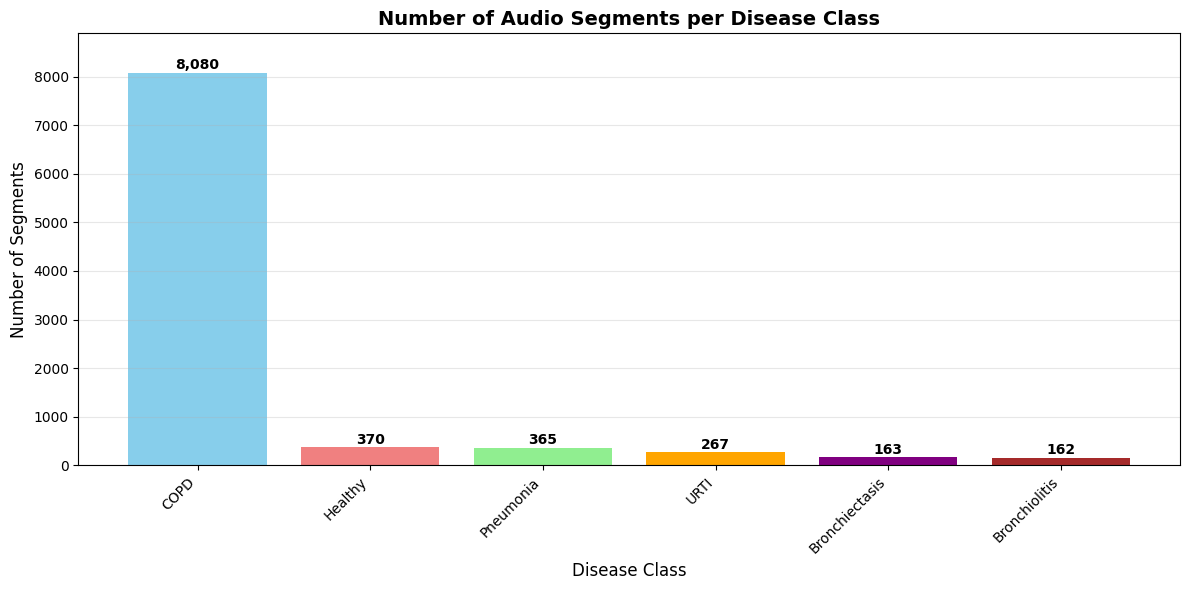

Segment counts per disease:
disease
COPD              8080
Healthy            370
Pneumonia          365
URTI               267
Bronchiectasis     163
Bronchiolitis      162
Name: count, dtype: int64


In [11]:
# Read segments data
seg_df = pd.read_csv("outputs/segmentation_outputs/segments.csv")

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

### Augmentation

In [12]:
def augment(
    seg_df,
    source_dir,
    save_dir,
    pdName,
    target_count=500,
    seed=42
):
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)

    updated_records = []

    # Reset output directory
    shutil.rmtree(save_dir, ignore_errors=True)
    os.makedirs(save_dir, exist_ok=True)

    for disease, group in seg_df.groupby("disease"):
        print(f"\nProcessing disease class: {disease}")

        originals = group["segment_file"].tolist()
        pids = group["pid"].tolist()
        files_with_pid = list(zip(originals, pids))

        # --------------------------------------------------
        # STEP 1: HARD CAP (Undersample if > 500)
        # --------------------------------------------------
        if len(files_with_pid) > target_count:
            files_with_pid = rng.sample(files_with_pid, target_count)
            print(f"\tUndersampled to {target_count}")

        current_count = len(files_with_pid)
        print(f"\tCurrent count after cap: {current_count}")

        # --------------------------------------------------
        # STEP 2: COPY ORIGINAL FILES
        # --------------------------------------------------
        for file, pid in files_with_pid:
            base_file = os.path.basename(file)
            src_path = os.path.join(source_dir, base_file)
            dest_path = os.path.join(save_dir, base_file)

            if not os.path.exists(src_path):
                raise FileNotFoundError(f"Missing file: {src_path}")

            shutil.copy(src_path, dest_path)

            updated_records.append({
                "segment_file": base_file,
                "pid": pid,
                "disease": disease,
            })

        # --------------------------------------------------
        # STEP 3: AUGMENT UNTIL 500
        # --------------------------------------------------
        needed = target_count - current_count

        if needed > 0:
            print(f"\tAugmenting {needed} samples...")

        aug_index = 1

        for _ in range(needed):
            f, pid = rng.choice(files_with_pid)

            src_path = os.path.join(source_dir, os.path.basename(f))
            y, sr = lb.load(src_path, sr=SR)

            # Choose random augmentation
            aug_fn = np_rng.choice(AUGS)
            y_aug = aug_fn(y, sr)

            base = os.path.splitext(os.path.basename(f))[0]
            save_name = f"{base}_aug-{disease}-{aug_index}.wav"
            save_path = os.path.join(save_dir, save_name)

            sf.write(save_path, y_aug, sr)

            updated_records.append({
                "segment_file": save_name,
                "pid": pid,
                "disease": disease,
            })

            aug_index += 1

        print(f"\tFinal count: {target_count}")

    df_final = pd.DataFrame(updated_records)
    df_final.to_csv(f"outputs/augmentation_outputs/{pdName}.csv", index=False)

    return df_final
  
train_augmented = augment(segments, 
    os.path.join(ROOT_DIR, SEGMENTS_DIR, "segments"),
    os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR),
    "segments"
)


Processing disease class: Bronchiectasis
	Current count after cap: 163
	Augmenting 337 samples...
	Final count: 500

Processing disease class: Bronchiolitis
	Current count after cap: 162
	Augmenting 338 samples...
	Final count: 500

Processing disease class: COPD
	Undersampled to 500
	Current count after cap: 500
	Final count: 500

Processing disease class: Healthy
	Current count after cap: 370
	Augmenting 130 samples...
	Final count: 500

Processing disease class: Pneumonia
	Current count after cap: 365
	Augmenting 135 samples...
	Final count: 500

Processing disease class: URTI
	Current count after cap: 267
	Augmenting 233 samples...
	Final count: 500


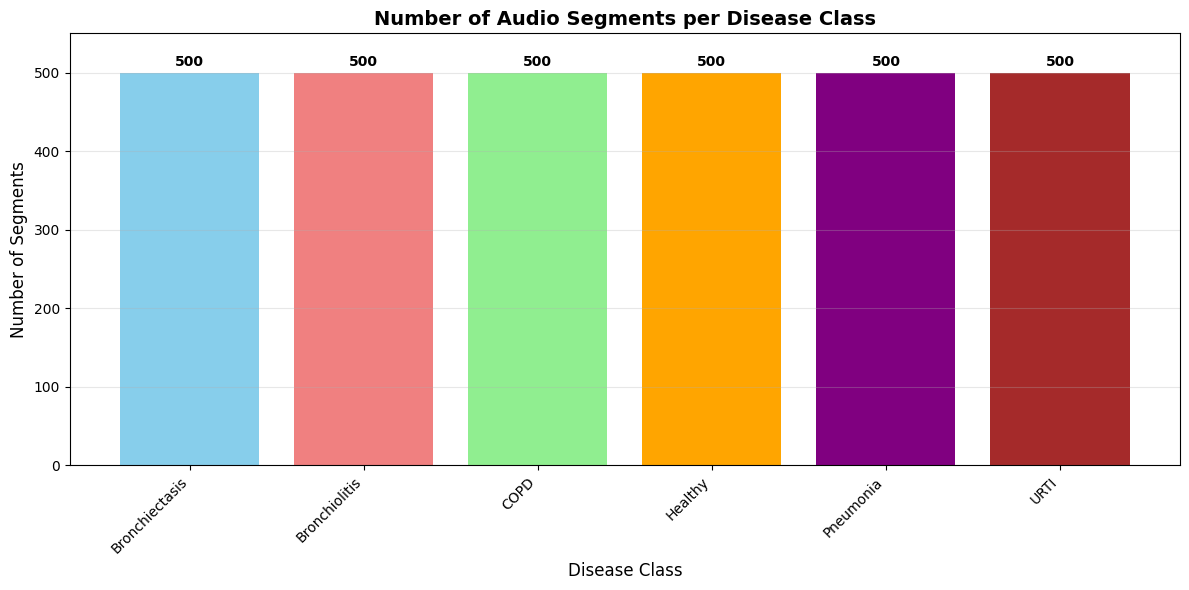

Segment counts per disease:
disease
Bronchiectasis    500
Bronchiolitis     500
COPD              500
Healthy           500
Pneumonia         500
URTI              500
Name: count, dtype: int64


In [13]:
# Read segments data
seg_df = pd.read_csv("outputs/augmentation_outputs/segments.csv")

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

### 3. Completely Random split Split


This script performs a random split for lung sound datasets (data leaks are expected).

Properties:
- Same patient could appear in train and test
- Model performance will look artificially high
- 90% development / 10% unseen
- 80/20 train/test inside development
- Reproducible with random seed

Input CSV format (one row per segment or file):
pid, disease, filepath,...

Output:
train_pids.txt
test_pids.txt
val_pids.txt


In [19]:
UNSEEN_RATIO = 0.10
TEST_RATIO_WITHIN_DEV = 0.20

def random_split(
    pid_df,
    segments_source_dir,
    output_root_dir,
    seed=42
):
    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # 1️⃣ Shuffle entire dataframe randomly (row-level)
    # --------------------------------------------------
    shuffled_df = pid_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    total = len(shuffled_df)

    unseen_size = int(round(total * UNSEEN_RATIO))

    val_df = shuffled_df.iloc[:unseen_size]
    dev_df = shuffled_df.iloc[unseen_size:]

    test_size = int(round(len(dev_df) * TEST_RATIO_WITHIN_DEV))

    test_df = dev_df.iloc[:test_size]
    train_df = dev_df.iloc[test_size:]

    # --------------------------------------------------
    # 2️⃣ Save CSV outputs
    # --------------------------------------------------
    split_csv_dir = "outputs/constrained_patient_split_outputs"
    os.makedirs(split_csv_dir, exist_ok=True)

    train_df.to_csv(f"{split_csv_dir}/train_df_after_split.csv", index=False)
    test_df.to_csv(f"{split_csv_dir}/test_df_after_split.csv", index=False)
    val_df.to_csv(f"{split_csv_dir}/val_df_after_split.csv", index=False)

    # --------------------------------------------------
    # 3️⃣ Prepare segment directories
    # --------------------------------------------------
    train_dir = os.path.join(output_root_dir, "train_segments")
    test_dir  = os.path.join(output_root_dir, "test_segments")
    val_dir   = os.path.join(output_root_dir, "val_segments")

    # Remove old folders
    shutil.rmtree(train_dir, ignore_errors=True)
    shutil.rmtree(test_dir, ignore_errors=True)
    shutil.rmtree(val_dir, ignore_errors=True)

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    # --------------------------------------------------
    # 4️⃣ Function to copy files
    # --------------------------------------------------
    def copy_files(df, destination_dir):
        for file in df["segment_file"]:
            src_path = os.path.join(segments_source_dir, file)


            dest_path = os.path.join(destination_dir, os.path.basename(file))
            shutil.copy(src_path, dest_path)

    # Copy segments
    copy_files(train_df, train_dir)
    copy_files(test_df, test_dir)
    copy_files(val_df, val_dir)

    print("\nSplit complete.")
    print(f"Train: {len(train_df)} segments")
    print(f"Test:  {len(test_df)} segments")
    print(f"Val:   {len(val_df)} segments")

    return train_df, test_df, val_df

train_strat, test_strat, val_strat = random_split(
    segments,
    os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR),
    os.path.join(ROOT_DIR, SPLIT_DIR),
    seed=42
)


FileNotFoundError: [Errno 2] No such file or directory: '/home/rithik-tank/Desktop/Auscultate/preprocessing/outputs/augmentation_outputs/train_segments/223_1b1_Pl_sc_Meditron_r-6790_s-0.wav'

In [ ]:
# Read segments data
seg_df = pd.read_csv('outputs/augmentation_outputs/val_segments.csv')

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

In [ ]:
# shutil.copytree(os.path.join(ROOT_DIR, SEGMENTS_DIR, "test_segments"),
#                 "../dataset/test-segments")

# shutil.copy(os.path.join(ROOT_DIR, "outputs/segmentation_outputs/test_segments.csv"),
#                 "../dataset/test_segments.csv")



# shutil.copytree(os.path.join(ROOT_DIR, SEGMENTS_DIR, "val_segments"),
#                 "../dataset/val-segments")

# shutil.copy(os.path.join(ROOT_DIR, "outputs/segmentation_outputs/val_segments.csv"),
#                 "../dataset/val_segments.csv")



shutil.copytree(os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR),
                "../dataset/train-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/augmentation_outputs/train_segments.csv"),
                "../dataset/train_segments.csv")



shutil.copytree(os.path.join(ROOT_DIR, TEST_SEGMENTS_AUGMENTED_DIR),
                "../dataset/test-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/augmentation_outputs/test_segments.csv"),
                "../dataset/test_segments.csv")


shutil.copytree(os.path.join(ROOT_DIR, VAL_SEGMENTS_AUGMENTED_DIR),
                "../dataset/val-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/augmentation_outputs/val_segments.csv"),
                "../dataset/val_segments.csv")